# Visualising Glove Data

In [15]:
#imports

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [16]:
def butter_lowpass_filter(series, cutoff_hz, fs_hz, order=3):
    """
    Apply a low-pass Butterworth filter to a 1D pandas Series.
    cutoff_hz: cutoff frequency (Hz)
    fs_hz: sampling frequency (Hz)
    order: filter order (3 in your case)
    """
    nyq = 0.5 * fs_hz
    normal_cutoff = cutoff_hz / nyq  # normalized 0–1
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, series.to_numpy())

### Importing CSV

In [17]:
csv_path = Path('glove_data_right_rock_33_2026-04-17_13-54-50.csv')
df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Loaded: glove_data_right_rock_33_2026-04-17_13-54-50.csv
Shape: 27 rows x 94 columns


,run_index,hand,glove_time_ms,time,palm_mcp_flex,palm_pip_flex,palm_mid_yaw,palm_mid_pitch,palm_mid_roll,palm_mid_ax,...,pinky_prox_roll,pinky_prox_ax,pinky_prox_ay,pinky_prox_az,wrist_ax,wrist_ay,wrist_az,wrist_heading,wrist_pitch,wrist_roll
0,33,RightGlove,989757,0,-1,-1,0,0,0,0,...,0.18,0.0,-0.01,-0.13,-2.91,-0.26,9.39,186.88,-17.44,1.69
1,33,RightGlove,990435,389,-1,-1,0,0,0,0,...,0.00,0.0,0.00,0.00,-2.97,-0.28,9.38,186.88,-17.50,1.69
2,33,RightGlove,990481,497,-1,-1,0,0,0,0,...,0.18,0.0,0.01,-0.12,-2.97,-0.29,9.32,186.88,-17.50,1.69
3,33,RightGlove,990590,672,-1,-1,0,0,0,0,...,0.18,0.0,0.00,-0.11,-2.94,-0.28,9.38,186.88,-17.44,1.69
4,33,RightGlove,990765,912,-1,-1,0,0,0,0,...,0.18,0.0,0.00,-0.12,-2.93,-0.30,9.56,186.94,-17.31,1.69


Removing the Palm flex and mid imu values

In [18]:
df = df.drop(['run_index','palm_mcp_flex', 'palm_pip_flex', 'palm_mid_yaw', 'palm_mid_pitch', 'palm_mid_roll', 'palm_mid_ax', 'palm_mid_ay', 'palm_mid_az'], axis=1)

df.head()

,hand,glove_time_ms,time,palm_prox_yaw,palm_prox_pitch,palm_prox_roll,palm_prox_ax,palm_prox_ay,palm_prox_az,thumb_mcp_flex,...,pinky_prox_roll,pinky_prox_ax,pinky_prox_ay,pinky_prox_az,wrist_ax,wrist_ay,wrist_az,wrist_heading,wrist_pitch,wrist_roll
0,RightGlove,989757,0,0.38,0.45,0.13,0.02,0.0,0.08,2032,...,0.18,0.0,-0.01,-0.13,-2.91,-0.26,9.39,186.88,-17.44,1.69
1,RightGlove,990435,389,0.00,0.00,0.00,0.00,0.0,0.00,2028,...,0.00,0.0,0.00,0.00,-2.97,-0.28,9.38,186.88,-17.50,1.69
2,RightGlove,990481,497,0.38,0.45,0.13,0.00,0.0,0.09,2027,...,0.18,0.0,0.01,-0.12,-2.97,-0.29,9.32,186.88,-17.50,1.69
3,RightGlove,990590,672,0.38,0.45,0.13,0.00,0.0,0.08,2005,...,0.18,0.0,0.00,-0.11,-2.94,-0.28,9.38,186.88,-17.44,1.69
4,RightGlove,990765,912,0.38,0.45,0.13,0.00,0.0,0.08,2031,...,0.18,0.0,0.00,-0.12,-2.93,-0.30,9.56,186.94,-17.31,1.69


In [19]:
FlexReadings = [c for c in df.columns if c.endswith('_flex') or c == "time"]
Flex_df= df.drop(['hand', 'glove_time_ms'], axis=1)
Flex_df.head()

,time,palm_prox_yaw,palm_prox_pitch,palm_prox_roll,palm_prox_ax,palm_prox_ay,palm_prox_az,thumb_mcp_flex,thumb_pip_flex,thumb_mid_yaw,...,pinky_prox_roll,pinky_prox_ax,pinky_prox_ay,pinky_prox_az,wrist_ax,wrist_ay,wrist_az,wrist_heading,wrist_pitch,wrist_roll
0,0,0.38,0.45,0.13,0.02,0.0,0.08,2032,2074,-0.78,...,0.18,0.0,-0.01,-0.13,-2.91,-0.26,9.39,186.88,-17.44,1.69
1,389,0.00,0.00,0.00,0.00,0.0,0.00,2028,2091,0.00,...,0.00,0.0,0.00,0.00,-2.97,-0.28,9.38,186.88,-17.50,1.69
2,497,0.38,0.45,0.13,0.00,0.0,0.09,2027,2093,-0.78,...,0.18,0.0,0.01,-0.12,-2.97,-0.29,9.32,186.88,-17.50,1.69
3,672,0.38,0.45,0.13,0.00,0.0,0.08,2005,2085,-0.78,...,0.18,0.0,0.00,-0.11,-2.94,-0.28,9.38,186.88,-17.44,1.69
4,912,0.38,0.45,0.13,0.00,0.0,0.08,2031,2095,-0.78,...,0.18,0.0,0.00,-0.12,-2.93,-0.30,9.56,186.94,-17.31,1.69


In [20]:
time_col = 'time' if 'time' in df.columns else df.columns[0]
cols = [c for c in FlexReadings if c != time_col]
print(cols)

['thumb_mcp_flex', 'thumb_pip_flex', 'index_mcp_flex', 'index_pip_flex', 'middle_mcp_flex', 'middle_pip_flex', 'ring_mcp_flex', 'ring_pip_flex', 'pinky_mcp_flex', 'pinky_pip_flex']


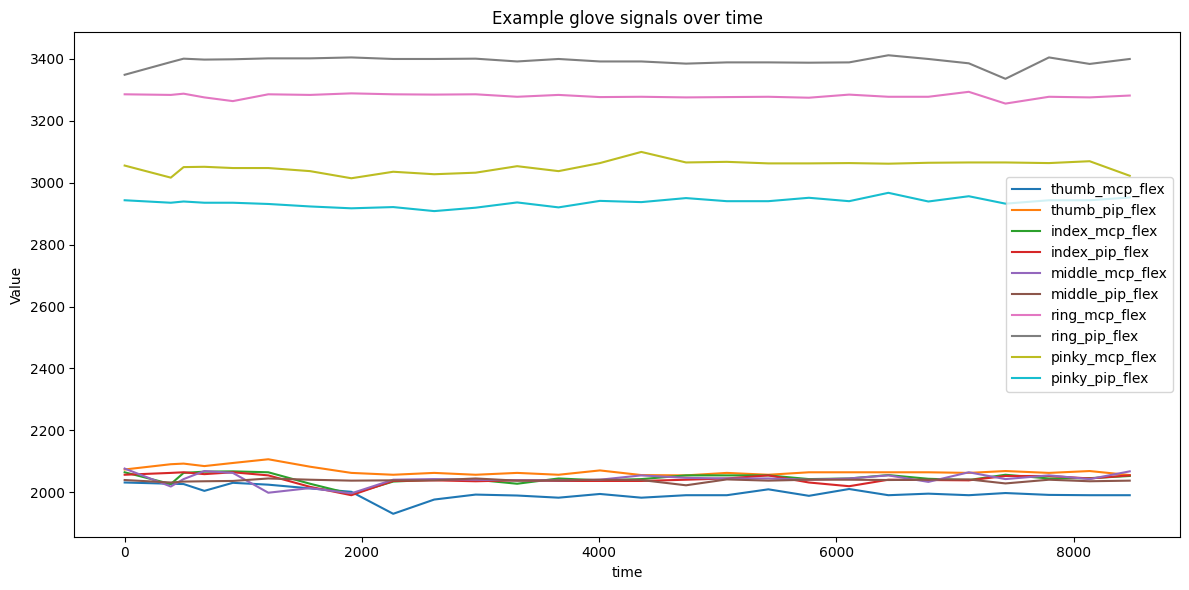

In [21]:
ax = Flex_df.plot(x=time_col, y=cols, figsize=(12, 6), title='Example glove signals over time')
ax.set_xlabel(time_col)
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()


### Adding Average Window Filter

Text(0.5, 0, 'time')

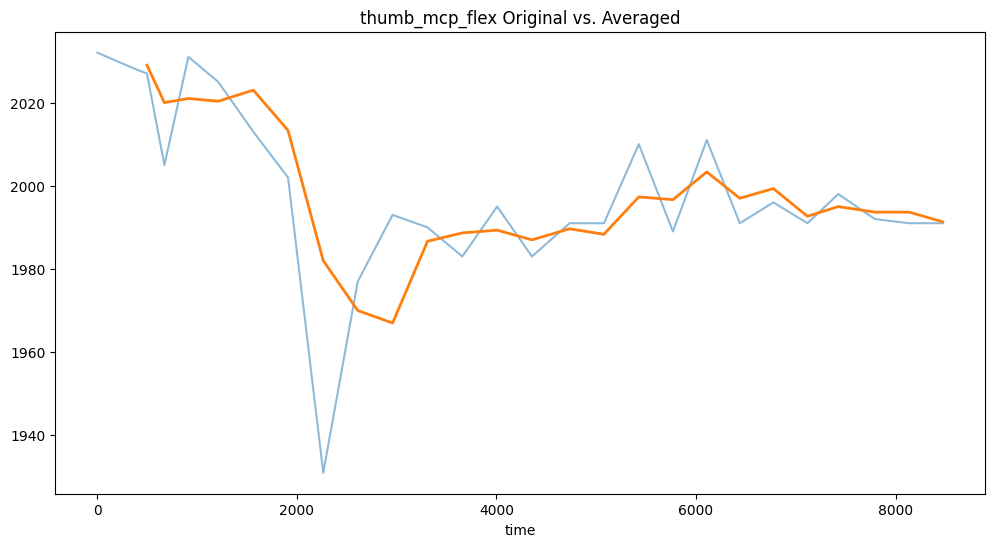

In [ ]:
Flex_df_avg_win = Flex_df.copy()

window_size = 3  # number of samples to average over

for col in Flex_df_avg_win.columns:
    Flex_df_avg_win[col + '_avg'] = Flex_df_avg_win[col].rolling(window=window_size, center=False).mean()

# Example: Plot original vs. averaged for one column
example_col = cols[0]  # just take the first flex column for demonstration


plt.figure(figsize=(12, 6))
plt.plot(Flex_df[time_col], Flex_df[example_col], label='Original', alpha=0.5)
plt.plot(Flex_df_avg_win[time_col], Flex_df_avg_win[example_col + '_avg'], label='Averaged', linewidth=2)
plt.title(f'{example_col} Original vs. Averaged')
plt.xlabel(time_col)        

### Adding Butterworth Filter

In [ ]:
Flex_df_bw = Flex_df.copy()

for col in Flex_df_avg_win.columns:
    